# 0 - Basic Validation

This notebook validates core data quality assumptions before modeling, with emphasis on:
- numeric outliers (boxplots + IQR summary),
- target distributions (`Opportunity Amount USD` and `Opportunity Result`),
- process consistency checks (`Total Days...` + stage ratios),
- repeated records per `Opportunity Number`.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from weirdness import digit_weirdness

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')


### Data loading note
This cell reads the raw Excel file used throughout the notebook.
All downstream checks assume this exact source and schema.


In [2]:
DATA_PATH = '../../data/raw/cars.xlsx'
df = pd.read_excel(DATA_PATH)

### Initial sanity profile
This quick profile confirms dataset size, column types, and a first sample preview.
It helps verify that parsing did not silently change data types.


In [3]:
print('shape:', df.shape)
print('columns:', len(df.columns))
display(df.dtypes)
display(df.head(3))


shape: (78025, 19)
columns: 19


Opportunity Number                            int64
Supplies Group                                  str
Supplies Subgroup                               str
Region                                          str
Route To Market                                 str
Elapsed Days In Sales Stage                   int64
Opportunity Result                              str
Sales Stage Change Count                      int64
Total Days Identified Through Closing         int64
Total Days Identified Through Qualified       int64
Opportunity Amount USD                        int64
Client Size By Revenue (USD)                    str
Client Size By Employee Count                   str
Revenue From Client Past Two Years (USD)        str
Competitor Type                                 str
Ratio Days Identified To Total Days         float64
Ratio Days Validated To Total Days          float64
Ratio Days Qualified To Total Days          float64
Deal Size Category (USD)                        str
dtype: objec

,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
0,1641984,Car Accessories,Exterior Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,More than 1M,More than 25K,0 (No business),Unknown,0.6964,0.1140,0.1542,10K or less
1,1658010,Car Accessories,Exterior Accessories,Pacific,Reseller,63,Loss,2,163,163,0,250K to 500K,More than 25K,0 (No business),Unknown,0.0000,1.0000,0.0000,10K or less
2,1674737,Performance & Non-auto,Motorcycle Parts,Pacific,Reseller,24,Won,7,82,82,7750,100K or less,1K or less,0 (No business),Unknown,1.0000,0.0000,0.0000,10K or less


In [4]:
df.describe(include='all')

,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD)
count,"78,025.0000",78025,78025,78025,78025,"78,025.0000",78025,"78,025.0000","78,025.0000","78,025.0000","78,025.0000",78025,78025,78025,68768,"78,025.0000","78,025.0000","78,025.0000",78025
unique,NaN,4,11,7,5,NaN,2,NaN,NaN,NaN,NaN,5,5,5,2,NaN,NaN,NaN,7
top,NaN,Car Accessories,Motorcycle Parts,Midwest,Fields Sales,NaN,Loss,NaN,NaN,NaN,NaN,100K or less,1K or less,0 (No business),Unknown,NaN,NaN,NaN,40K to 50K
freq,NaN,49810,15174,21020,37262,NaN,60398,NaN,NaN,NaN,NaN,59504,59348,69208,56724,NaN,NaN,NaN,18074
mean,"7,653,428.7343",NaN,NaN,NaN,NaN,43.5953,NaN,2.9557,16.7284,16.3143,"91,637.2607",NaN,NaN,NaN,NaN,0.2031,0.4883,0.1850,NaN
std,"1,054,847.7631",NaN,NaN,NaN,NaN,26.5856,NaN,1.4972,16.7296,16.5626,"133,161.0292",NaN,NaN,NaN,NaN,0.3650,0.4481,0.3403,NaN
min,"1,641,984.0000",NaN,NaN,NaN,NaN,0.0000,NaN,1.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN
25%,"6,900,423.0000",NaN,NaN,NaN,NaN,19.0000,NaN,2.0000,4.0000,4.0000,"15,000.0000",NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,NaN
50%,"7,545,569.0000",NaN,NaN,NaN,NaN,43.0000,NaN,3.0000,12.0000,12.0000,"49,000.0000",NaN,NaN,NaN,NaN,0.0000,0.4480,0.0000,NaN
75%,"8,228,329.0000",NaN,NaN,NaN,NaN,65.0000,NaN,3.0000,24.0000,24.0000,"105,099.0000",NaN,NaN,NaN,NaN,0.1972,1.0000,0.1886,NaN


## 1) Target distributions


### Why target distributions are checked
Before cleaning rules, we inspect target imbalance and numeric skew.
This is useful to interpret later outlier and quality decisions.


In [5]:
target_col_amount = 'Opportunity Amount USD'
target_col_result = 'Opportunity Result'

result_dist = (
    df[target_col_result]
    .value_counts(dropna=False)
    .rename('count')
    .to_frame()
)
result_dist['pct'] = (result_dist['count'] / len(df) * 100).round(2)

amount_summary = df[target_col_amount].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame('value')

print('Opportunity Result distribution:')
display(result_dist)
print('Opportunity Amount USD summary:')
display(amount_summary)


Opportunity Result distribution:


,count,pct
Opportunity Result,,
Loss,60398,77.4100
Won,17627,22.5900


Opportunity Amount USD summary:


,value
count,"78,025.0000"
mean,"91,637.2607"
std,"133,161.0292"
min,0.0000
1%,0.0000
5%,"1,192.8000"
25%,"15,000.0000"
50%,"49,000.0000"
75%,"105,099.0000"
95%,"350,000.0000"


Table for target plots:


,Opportunity Result,count,pct
0,Loss,60398,77.4100
1,Won,17627,22.5900


,value
count,"78,025.0000"
mean,"91,637.2607"
std,"133,161.0292"
min,0.0000
1%,0.0000
5%,"1,192.8000"
25%,"15,000.0000"
50%,"49,000.0000"
75%,"105,099.0000"
95%,"350,000.0000"


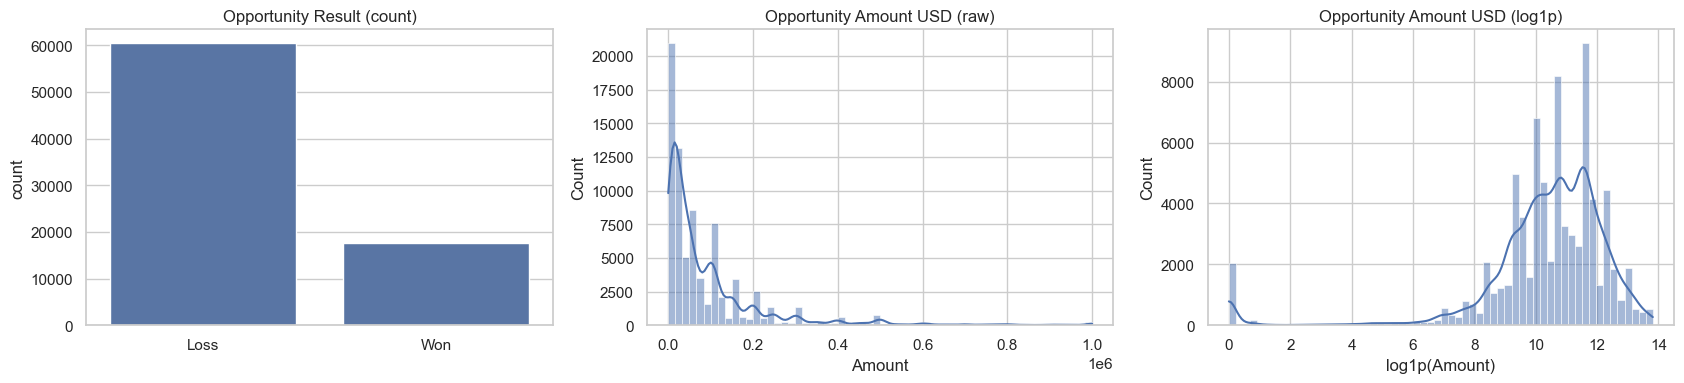

In [6]:
result_plot_table = (
    df[target_col_result]
    .value_counts(dropna=False)
    .rename('count')
    .rename_axis(target_col_result)
    .reset_index()
)
result_plot_table['pct'] = (result_plot_table['count'] / len(df) * 100).round(2)

amount_plot_table = (
    df[target_col_amount]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .rename('value')
    .to_frame()
)

print('Table for target plots:')
display(result_plot_table)
display(amount_plot_table)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

order = df[target_col_result].value_counts().index
sns.countplot(data=df, x=target_col_result, order=order, ax=axes[0])
axes[0].set_title('Opportunity Result (count)')
axes[0].set_xlabel('')

sns.histplot(df[target_col_amount], bins=60, kde=True, ax=axes[1])
axes[1].set_title('Opportunity Amount USD (raw)')
axes[1].set_xlabel('Amount')

sns.histplot(np.log1p(df[target_col_amount]), bins=60, kde=True, ax=axes[2])
axes[2].set_title('Opportunity Amount USD (log1p)')
axes[2].set_xlabel('log1p(Amount)')

plt.tight_layout()


## 2) Numeric outliers (IQR + boxplots)


Table for boxplots (IQR bounds + outlier counts):


,q1,q3,iqr,lower_bound,upper_bound,outlier_count
Ratio Days Identified To Total Days,0.0000,0.1972,0.1972,-0.2958,0.4931,14983
Ratio Days Qualified To Total Days,0.0000,0.1886,0.1886,-0.2828,0.4714,14948
Sales Stage Change Count,2.0000,3.0000,1.0000,0.5000,4.5000,9340
Opportunity Amount USD,"15,000.0000","105,099.0000","90,099.0000","-120,148.5000","240,247.5000",7273
Total Days Identified Through Closing,4.0000,24.0000,20.0000,-26.0000,54.0000,2706
Total Days Identified Through Qualified,4.0000,24.0000,20.0000,-26.0000,54.0000,2566
Elapsed Days In Sales Stage,19.0000,65.0000,46.0000,-50.0000,134.0000,6
Ratio Days Validated To Total Days,0.0000,1.0000,1.0000,-1.5000,2.5000,0


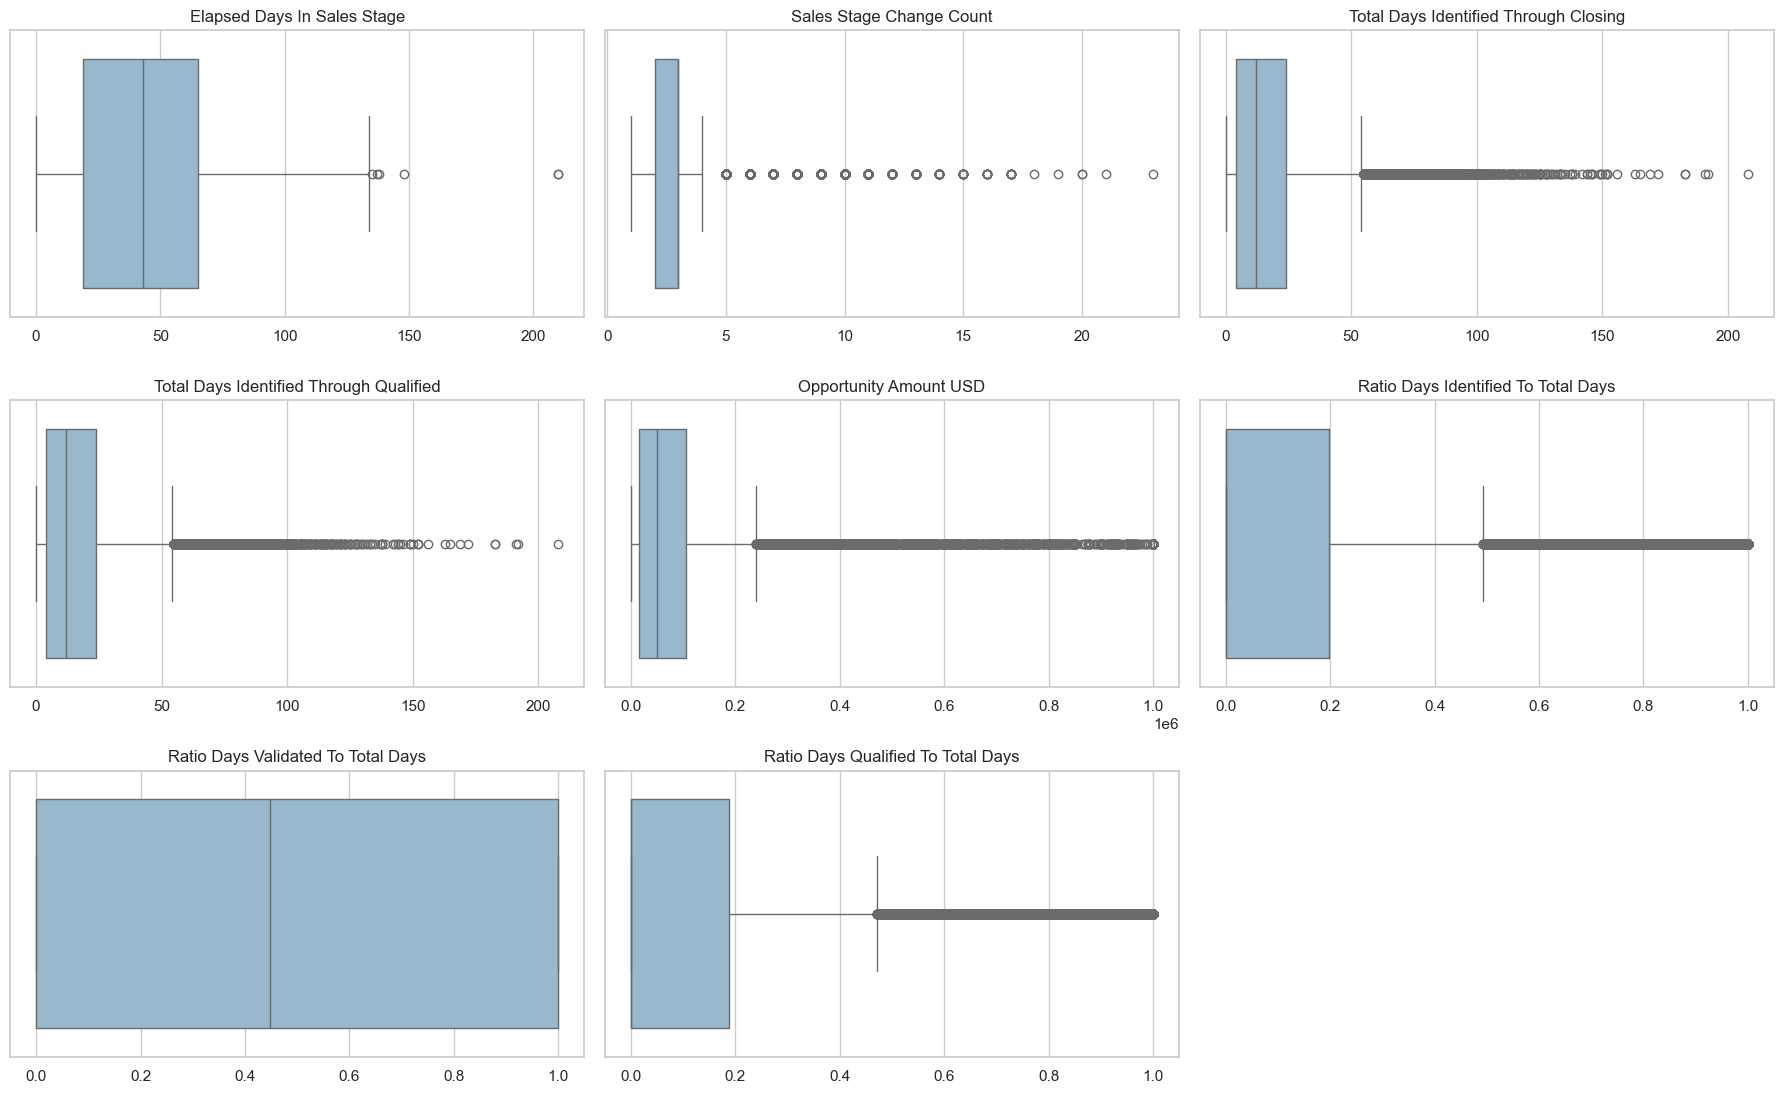

In [7]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('Opportunity Number')  # Exclude ID from numeric variables used for checks

q1_plot = df[numeric_cols].quantile(0.25)
q3_plot = df[numeric_cols].quantile(0.75)
iqr_plot = q3_plot - q1_plot
lower_plot = q1_plot - 1.5 * iqr_plot
upper_plot = q3_plot + 1.5 * iqr_plot

boxplot_table = pd.concat([
    q1_plot.rename('q1'),
    q3_plot.rename('q3'),
    iqr_plot.rename('iqr'),
    lower_plot.rename('lower_bound'),
    upper_plot.rename('upper_bound'),
    (((df[numeric_cols] < lower_plot) | (df[numeric_cols] > upper_plot)).sum()).rename('outlier_count')
], axis=1).sort_values('outlier_count', ascending=False)

print('Table for boxplots (IQR bounds + outlier counts):')
display(boxplot_table)

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.7 * nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='#8fbad6')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()


### IQR outlier method
This cell computes IQR-based bounds per numeric variable.
The same bounds are later reused for row-level problem tagging.


In [8]:
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_count = ((df[numeric_cols] < lower) | (df[numeric_cols] > upper)).sum().rename('outlier_count')
outlier_pct = (outlier_count / len(df) * 100).rename('outlier_pct')

outlier_table = pd.concat([
    q1.rename('q1'),
    q3.rename('q3'),
    iqr.rename('iqr'),
    lower.rename('lower_bound'),
    upper.rename('upper_bound'),
    outlier_count,
    outlier_pct.round(2)
], axis=1).sort_values('outlier_pct', ascending=False)

outlier_table


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
Ratio Days Identified To Total Days,0.0000,0.1972,0.1972,-0.2958,0.4931,14983,19.2000
Ratio Days Qualified To Total Days,0.0000,0.1886,0.1886,-0.2828,0.4714,14948,19.1600
Sales Stage Change Count,2.0000,3.0000,1.0000,0.5000,4.5000,9340,11.9700
Opportunity Amount USD,"15,000.0000","105,099.0000","90,099.0000","-120,148.5000","240,247.5000",7273,9.3200
Total Days Identified Through Closing,4.0000,24.0000,20.0000,-26.0000,54.0000,2706,3.4700
Total Days Identified Through Qualified,4.0000,24.0000,20.0000,-26.0000,54.0000,2566,3.2900
Elapsed Days In Sales Stage,19.0000,65.0000,46.0000,-50.0000,134.0000,6,0.0100
Ratio Days Validated To Total Days,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0000


## 3) Process consistency checks


In [9]:
total_days_col = 'Total Days Identified Through Closing'
total_siebel_col = 'Total Days Identified Through Qualified'
ratio_cols = [
    'Ratio Days Identified To Total Days',
    'Ratio Days Validated To Total Days',
    'Ratio Days Qualified To Total Days'
]

### 3.1) Total Days consistency

Assumption: `Total Days in Sales Process` should be > 0 for all records, as it represents the duration of the sales process.


In [10]:
df["total_days_zero"] = df[total_days_col] == 0
df["Opportunity Result Bool"] = df["Opportunity Result"] == 'Won'

In [11]:
df.groupby("total_days_zero")[["Opportunity Result Bool", "Opportunity Amount USD"]].agg(['count', 'mean'])

Opportunity Result Bool        Opportunity Amount USD  \
                                  count   mean                  count   
total_days_zero                                                         
False                             69736 0.2035                  69736   
True                               8289 0.4144                   8289   

                             
                       mean  
total_days_zero              
False           93,852.3172  
True            73,001.8190

Apparently there are some records with `Total Days in Sales Process` = 0, and weirdly they have a higher win rate than the rest of the data. This is a red flag that these records might be erroneous or they represent after-the-fact records that are useless for modeling. We should investigate further before modeling.

## 3.2 Other consistency checks (stage ratios)

Assumption: Total days and ratios of days in each stage should be consistent with the expected sales process. For example, if `Total Days in Sales Process` is 10, we would expect that the sum of days in each stage equals 10, and that the ratios of days in each stage are reasonable (e.g., not all days spent in one stage).

### Process-ratio consistency checks
These checks validate whether stage ratios and total-days columns agree.
Rows failing these conditions are grouped under `ratio_problem` in the final tagging.


In [12]:
check = df[[total_days_col, total_siebel_col] + ratio_cols].copy()
check['ratio_sum'] = check[ratio_cols].sum(axis=1)
check['implied_days_from_ratios'] = check['ratio_sum'] * check[total_days_col]
check['ratio_sum_abs_error'] = (check['ratio_sum'] - 1.0).abs()
check['siebel_le_total_days'] = check[total_siebel_col] <= check[total_days_col]

consistency_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'rows_total_days_negative',
        'rows_total_siebel_negative',
        'rows_total_siebel_gt_total_days',
        'rows_ratio_sum_not_close_to_1 (tol=0.01)',
        'rows_any_ratio_outside_0_1',
        'rows_ratio_days_implied_diff_gt_1day'
    ],
    'count': [
        len(check),
        int((check[total_days_col] < 0).sum()),
        int((check[total_siebel_col] < 0).sum()),
        int((~check['siebel_le_total_days']).sum()),
        int((check['ratio_sum_abs_error'] > 0.01).sum()),
        int(((check[ratio_cols] < 0) | (check[ratio_cols] > 1)).any(axis=1).sum()),
        int(((check['implied_days_from_ratios'] - check[total_days_col]).abs() > 1).sum())
    ]
})

consistency_summary['pct'] = (consistency_summary['count'] / len(check) * 100).round(2)

consistency_summary


,metric,count,pct
0,rows_total,78025,100.0000
1,rows_total_days_negative,0,0.0000
2,rows_total_siebel_negative,0,0.0000
3,rows_total_siebel_gt_total_days,0,0.0000
4,rows_ratio_sum_not_close_to_1 (tol=0.01),12921,16.5600
5,rows_any_ratio_outside_0_1,0,0.0000
6,rows_ratio_days_implied_diff_gt_1day,4127,5.2900


Table for ratio-sum distribution plot:


,value
count,"78,025.0000"
mean,0.8764
std,0.3150
min,0.0000
1%,0.0000
5%,0.0000
25%,1.0000
50%,1.0000
75%,1.0000
95%,1.0000


<Axes: >

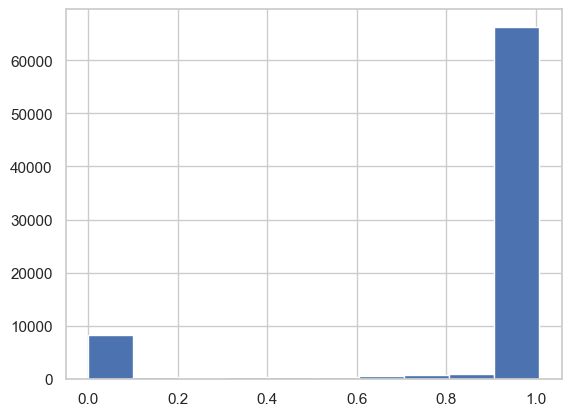

In [13]:
ratio_sum_table = check['ratio_sum'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).rename('value').to_frame()
ratio_sum_table.loc['rows_not_close_to_1_tol_0.01', 'value'] = int((check['ratio_sum_abs_error'] > 0.01).sum())
ratio_sum_table.loc['pct_not_close_to_1_tol_0.01', 'value'] = round((check['ratio_sum_abs_error'] > 0.01).mean() * 100, 2)

print('Table for ratio-sum distribution plot:')
display(ratio_sum_table)

check['ratio_sum'].hist()


In [14]:
worst_ratio_rows = (
    check.assign(opportunity_number=df['Opportunity Number'])
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 rows by ratio-sum error:')
display(worst_ratio_rows[['opportunity_number', total_days_col, total_siebel_col] + ratio_cols + ['ratio_sum', 'ratio_sum_abs_error']])


Top 15 rows by ratio-sum error:


,opportunity_number,Total Days Identified Through Closing,Total Days Identified Through Qualified,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,ratio_sum,ratio_sum_abs_error
78024,10094255,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40772,9469192,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40748,9468343,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40747,9468330,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40745,9467753,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40744,9467649,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40742,9467239,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40730,9466724,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40724,9466450,0,0,0.0000,0.0000,0.0000,0.0000,1.0000
40713,9466078,0,0,0.0000,0.0000,0.0000,0.0000,1.0000


### 3.3) Early-days focus (0-1 days) for top day-related issues\n

In [15]:
top_day_issues = (
    check.assign(
        opportunity_number=df['Opportunity Number'],
        opportunity_result=df['Opportunity Result']
    )
    .sort_values('ratio_sum_abs_error', ascending=False)
    .head(15)
)

print('Top 15 day-consistency issues (sorted by ratio-sum error):')
display(
    top_day_issues[[
        'opportunity_number',
        'opportunity_result',
        total_days_col,
        total_siebel_col,
        'ratio_sum',
        'ratio_sum_abs_error'
    ]]
)

early_issue_summary = pd.DataFrame({
    'metric': [
        'top15_count',
        'top15_with_total_days_0_1',
        'top15_pct_total_days_0_1',
        'full_dataset_with_total_days_0_1',
        'full_dataset_pct_total_days_0_1'
    ],
    'value': [
        len(top_day_issues),
        int((top_day_issues[total_days_col] <= 1).sum()),
        round((top_day_issues[total_days_col] <= 1).mean() * 100, 2),
        int((check[total_days_col] <= 1).sum()),
        round((check[total_days_col] <= 1).mean() * 100, 2)
    ]
})

print('0-1 day concentration summary:')
display(early_issue_summary)


Top 15 day-consistency issues (sorted by ratio-sum error):


,opportunity_number,opportunity_result,Total Days Identified Through Closing,Total Days Identified Through Qualified,ratio_sum,ratio_sum_abs_error
78024,10094255,Loss,0,0,0.0000,1.0000
40772,9469192,Won,0,0,0.0000,1.0000
40748,9468343,Loss,0,0,0.0000,1.0000
40747,9468330,Loss,0,0,0.0000,1.0000
40745,9467753,Loss,0,0,0.0000,1.0000
40744,9467649,Loss,0,0,0.0000,1.0000
40742,9467239,Won,0,0,0.0000,1.0000
40730,9466724,Won,0,0,0.0000,1.0000
40724,9466450,Won,0,0,0.0000,1.0000
40713,9466078,Loss,0,0,0.0000,1.0000


0-1 day concentration summary:


,metric,value
0,top15_count,15.0000
1,top15_with_total_days_0_1,15.0000
2,top15_pct_total_days_0_1,100.0000
3,full_dataset_with_total_days_0_1,"11,618.0000"
4,full_dataset_pct_total_days_0_1,14.8900


Table for win/loss-by-days-bin plot (first bin = 0-1):


,days_bin,opportunities,win_probability
0,0-1,11618,0.4194
1,2-3,6100,0.4621
2,4-7,10487,0.3358
3,8-14,14817,0.2086
4,15-30,21951,0.1091
5,31-60,11211,0.0712
6,61-90,1518,0.0672
7,91-180,318,0.0849
8,181-365,5,0.2000
9,366+,0,NaN


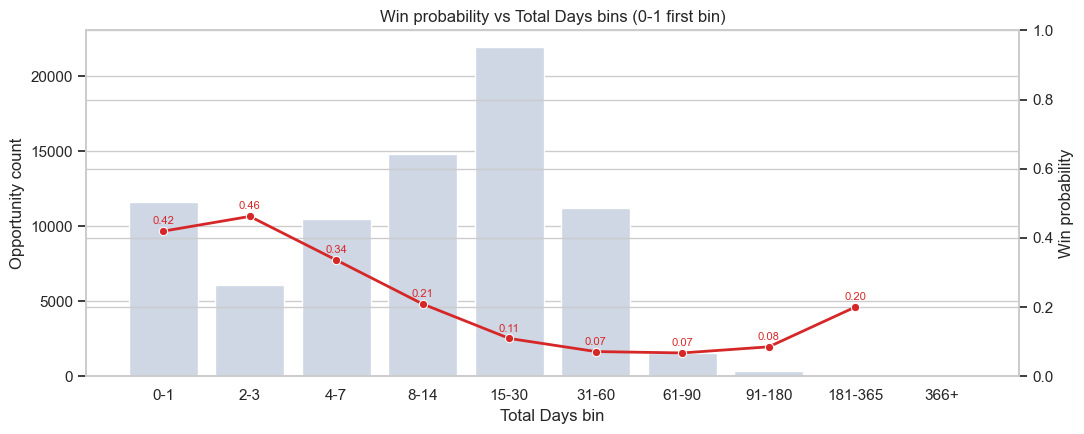

In [16]:
bin_edges = [-0.1, 1, 3, 7, 14, 30, 60, 90, 180, 365, np.inf]
bin_labels = ['0-1', '2-3', '4-7', '8-14', '15-30', '31-60', '61-90', '91-180', '181-365', '366+']

tmp = df[[total_days_col, 'Opportunity Result']].copy()
tmp['days_bin'] = pd.cut(tmp[total_days_col], bins=bin_edges, labels=bin_labels, include_lowest=True)
tmp['is_win'] = tmp['Opportunity Result'].eq('Won').astype(int)

winloss_by_bin = (
    tmp.groupby('days_bin', observed=False)
    .agg(
        opportunities=('is_win', 'size'),
        win_probability=('is_win', 'mean')
    )
    .reset_index()
)
winloss_by_bin['win_probability'] = winloss_by_bin['win_probability'].round(4)

print('Table for win/loss-by-days-bin plot (first bin = 0-1):')
display(winloss_by_bin)

fig, ax1 = plt.subplots(figsize=(11, 4.5))
sns.barplot(data=winloss_by_bin, x='days_bin', y='opportunities', color='#cbd5e8', ax=ax1)
ax1.set_ylabel('Opportunity count')
ax1.set_xlabel('Total Days bin')
ax1.set_title('Win probability vs Total Days bins (0-1 first bin)')

ax2 = ax1.twinx()
sns.lineplot(data=winloss_by_bin, x='days_bin', y='win_probability', marker='o', color='#d62728', linewidth=2, ax=ax2)
ax2.set_ylabel('Win probability')
ax2.set_ylim(0, 1)

for i, r in winloss_by_bin.iterrows():
    ax2.text(i, r['win_probability'] + 0.02, f"{r['win_probability']:.2f}", ha='center', fontsize=8, color='#d62728')

plt.tight_layout()


There are two modalities in the `Total Days in Sales Process` distribution: one at 0-1 (maybe up to 3) days and another around up to 90 days. The 0-day modality is particularly concerning, as it suggests that there are many records where the sales process duration is recorded as zero, which is likely incorrect. This could indicate data entry errors or a misunderstanding of what the `Total Days in Sales Process` field represents.

### 3.4) Exact amount values

Numbers may be rounded or truncated, indicating potential data entry issues or limited precision in the Opportunity Amount USD field. This can be assessed by analyzing the distribution of last digits and identifying excess frequency in round values (e.g., 1000, 5000).

We define a weirdness metric (see weirdness.py) as a proxy for how atypical a number is based on its digits.

**Hypothesis:** Weirdness should behave like noise. If it behaves like signal, something is off.

**Note:** This metric is heuristic and requires further validation. It may not capture all forms of data quality issues, and results should be interpreted in the context of underlying business processes.

<Axes: >

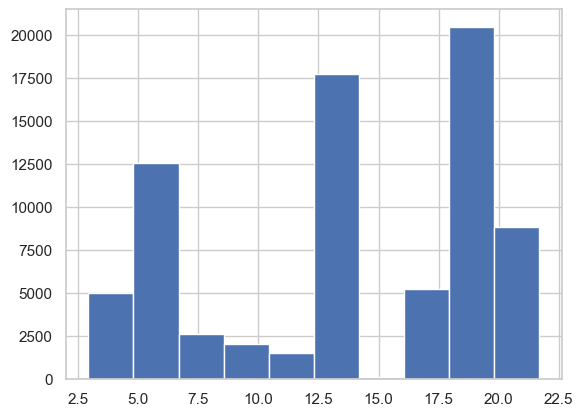

In [20]:
df["opportunity_amount_weirdness"] = (df[df["Opportunity Amount USD"] > 0]["Opportunity Amount USD"]).apply(digit_weirdness)
df["opportunity_amount_weirdness"].hist()

In [44]:
df[["opportunity_amount_weirdness","Opportunity Amount USD"]].sort_values("opportunity_amount_weirdness", ascending=False).head(10)

,opportunity_amount_weirdness,Opportunity Amount USD
74976,21.6880,111111
17556,21.6880,111111
33132,21.6880,222222
16119,21.6880,111111
36570,21.6880,111111
15491,21.6880,111111
12998,21.6880,111111
15634,21.6880,111111
23845,21.6880,111111
15314,21.6880,111111


In [45]:
df[["opportunity_amount_weirdness","Opportunity Amount USD"]].sort_values("opportunity_amount_weirdness", ascending=True).head(10)

,opportunity_amount_weirdness,Opportunity Amount USD
17800,2.9250,109875
38105,2.9250,134965
5879,2.9250,168435
22154,2.9250,798325
18035,2.9250,276315
63111,2.9250,682195
2071,2.9250,426315
46324,2.9250,203945
61428,2.9250,319825
10068,2.9250,276315


In [41]:
df.groupby(pd.qcut(df["opportunity_amount_weirdness"], q=4))["Opportunity Amount USD"].agg(["count","mean","std"])

,count,mean,std
opportunity_amount_weirdness,,,
"(2.924, 8.238]",19198,"82,213.0211","131,011.7996"
"(8.238, 14.014]",22158,"107,885.5084","128,378.4631"
"(14.014, 18.382]",25768,"39,858.4018","41,414.5280"
"(18.382, 21.688]",8854,"243,288.1519","198,034.1813"


<Axes: xlabel='Total Days Identified Through Closing'>

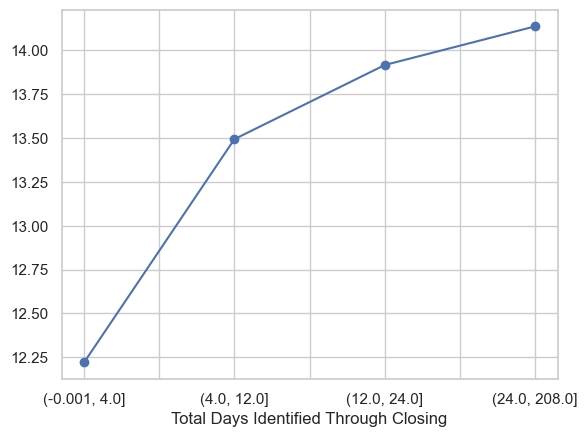

In [31]:
df.groupby(pd.qcut(df[total_days_col], q=4))["opportunity_amount_weirdness"].mean().plot(marker='o')

<Axes: xlabel='Sales Stage Change Count'>

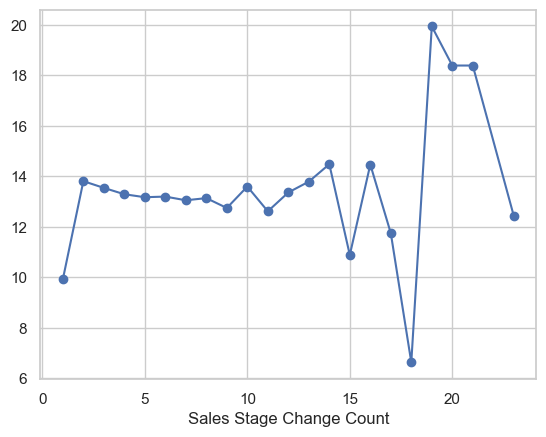

In [33]:
df.groupby("Sales Stage Change Count")["opportunity_amount_weirdness"].mean().plot(marker='o')

<Axes: xlabel='Opportunity Result'>

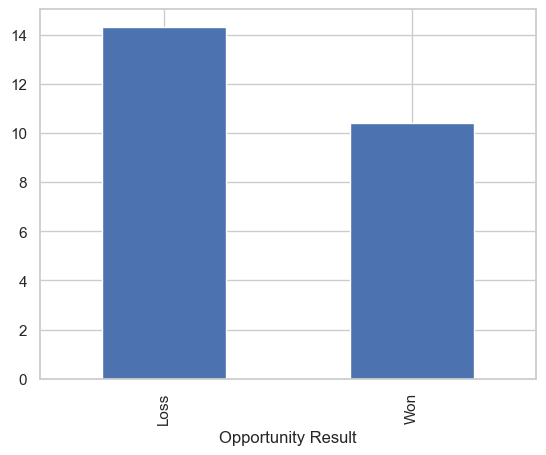

In [49]:
df.groupby("Opportunity Result")["opportunity_amount_weirdness"].mean().plot.bar()

There are some correlations between weirdness and other variables, which suggests that the weirdness metric is not purely noise and may be capturing some systematic patterns in the data, probably related to data entry practices or business process updates as the opportunity progresses through stages. For example, the fact that weirdness is lower for won opportunities could indicate that salespeople are more careful when entering amounts for deals they expect to win, or that they update the amounts to more precise values as the deal progresses.

**Data generating process related question**: Is the amount updated over time or fixed? 

### 3.3) Final summary of process consistency checks

In [50]:
plot_consistency_table = pd.DataFrame({
    'metric': [
        'rows_total',
        'ratio_sum_mean',
        'ratio_sum_median',
        'ratio_sum_std',
        'rows_ratio_sum_not_close_to_1_tol_0.01',
        'pct_ratio_sum_not_close_to_1_tol_0.01',
        'corr_total_days_vs_total_siebel',
        'mae_total_days_vs_total_siebel'
    ],
    'value': [
        len(check),
        float(check['ratio_sum'].mean()),
        float(check['ratio_sum'].median()),
        float(check['ratio_sum'].std()),
        int((check['ratio_sum_abs_error'] > 0.01).sum()),
        round((check['ratio_sum_abs_error'] > 0.01).mean() * 100, 2),
        float(check[[total_days_col, total_siebel_col]].corr().iloc[0, 1]),
        float((check[total_days_col] - check[total_siebel_col]).abs().mean())
    ]
})

print('Table for consistency plots:')
display(plot_consistency_table)


Table for consistency plots:


,metric,value
0,rows_total,"78,025.0000"
1,ratio_sum_mean,0.8764
2,ratio_sum_median,1.0000
3,ratio_sum_std,0.3150
4,rows_ratio_sum_not_close_to_1_tol_0.01,"12,921.0000"
5,pct_ratio_sum_not_close_to_1_tol_0.01,16.5600
6,corr_total_days_vs_total_siebel,0.9837
7,mae_total_days_vs_total_siebel,0.4140


## 4) ID analysis (potential repeated `Opportunity Number` records)


In [51]:
id_col = 'Opportunity Number'

id_counts = df[id_col].value_counts(dropna=False)
rows_with_repeated_id = int(id_counts[id_counts > 1].sum())
ids_with_repeats = int((id_counts > 1).sum())

dup_summary = pd.DataFrame({
    'metric': [
        'rows_total',
        'unique_ids',
        'ids_with_more_than_one_record',
        'rows_belonging_to_repeated_ids',
        'max_rows_for_single_id'
    ],
    'value': [
        len(df),
        int(df[id_col].nunique(dropna=False)),
        ids_with_repeats,
        rows_with_repeated_id,
        int(id_counts.max())
    ]
})

dup_summary


,metric,value
0,rows_total,78025
1,unique_ids,77829
2,ids_with_more_than_one_record,183
3,rows_belonging_to_repeated_ids,379
4,max_rows_for_single_id,4


### Duplicate-ID interpretation
Repeated IDs are split into exact repeats vs changed-state repeats.
This distinction feeds `totally_repeated_row` and `partially_repeated_row` tags.


In [52]:
duplicate_rows = df[df[id_col].duplicated(keep=False)].copy()
non_id_cols = [c for c in df.columns if c != id_col]

id_state_summary = []
for oid, grp in duplicate_rows.groupby(id_col, sort=False):
    distinct_states = grp[non_id_cols].drop_duplicates().shape[0]
    id_state_summary.append({
        id_col: int(oid),
        'rows_for_id': int(len(grp)),
        'distinct_states_excl_id': int(distinct_states),
        'is_exact_repeat_only': bool(distinct_states == 1)
    })

id_state_summary = pd.DataFrame(id_state_summary)

print('Duplicate-ID detail sample:')
display(id_state_summary.sort_values(['rows_for_id', 'distinct_states_excl_id'], ascending=False).head(20))


Duplicate-ID detail sample:


,Opportunity Number,rows_for_id,distinct_states_excl_id,is_exact_repeat_only
42,7281765,4,3,False
181,9782603,4,2,False
79,8093335,4,1,True
32,6835459,3,3,False
107,4787647,3,3,False
146,7239544,3,3,False
50,7463337,3,2,False
170,8445253,3,2,False
25,6704540,3,1,True
82,8133081,3,1,True


This shows to things about the data:
- 1. The dataset is mostly made of single slice records per `Opportunity Number`, which means that each record represents a unique sales opportunity. This means the dataset is partially useful for modeling, since it will be biased (hopefully if every opportunity is represented as its end) towards the most updated stage of the sales process (per record), but it is not completely useless.
- 2. There are some repeated `Opportunity Number` records, which could indicate that there are multiple records for the same sales opportunity. This could be due to data entry errors, or it could be that the dataset includes multiple records for the same opportunity at different stages of the sales process. This is a red flag that we need to investigate further before modeling, as it could lead to data leakage if we have multiple records for the same opportunity in both the training and test sets.

**NOTE**: It would be much better if the dataset had a record per opportunity update (i.e., a long panel data series of records per opportunity), but it seems that the dataset is more of a snapshot of the most updated record per opportunity, with some duplicates. This limits the types of models we can build, as we cannot leverage temporal dynamics in the sales process.

## 5) Relationship between Opportunity Amount and Deal Size

In [58]:
df.groupby("Deal Size Category (USD)")["Opportunity Amount USD"].agg(['count', 'mean', 'std', 'min', 'max'])

,count,mean,std,min,max
Deal Size Category (USD),,,,,
10K or less,12095,"3,571.7922","2,992.4459",0,9999
10K to 20K,15123,"15,684.0934","4,415.6807",10000,24999
20K to 30K,11968,"33,690.4013","6,827.1244",25000,49999
30K to 40K,13628,"63,681.2595","14,353.8390",50000,99999
40K to 50K,18074,"139,914.6179","40,413.7278",100000,249999
50K to 60K,4934,"326,780.1336","68,998.0282",250000,499999
More than 60K,2203,"661,552.8765","170,983.8367",500000,1000000


The relationship between `Opportunity Amount USD` and `Deal Size Category (USD)` is weird and show amounts that exceed the maximum of their category.

The recommendation is not to use the `Deal Size Category (USD)` variable, as it seems to be inconsistent with the `Opportunity Amount USD` variable, and could also be considered target leakage if it is derived from the `Opportunity Amount USD` variable.

## 6) Final row-level problem tagging

This section creates a final per-row quality view with:
- `problem_tags`: list of all detected issues per row,
- `problem_count`: number of issues in that list,
- `partial_repeat_is_latest_id_appearance`: marker for the latest row among partial duplicates of the same ID.

### Final tagging guide
This cell creates row-level boolean flags, `problem_tags`, and `problem_count`.
Use this as the canonical quality layer before any export.


In [66]:
df_tagged = df.copy()
df_tagged['row_position'] = np.arange(len(df_tagged))

# Outlier thresholds from previously computed IQR bounds
amount_lower = lower[target_col_amount]
amount_upper = upper[target_col_amount]
days_lower = lower[total_days_col]
days_upper = upper[total_days_col]

# Ratio-related issues
ratio_sum_not_close = check['ratio_sum_abs_error'] > 0.01
ratio_outside_0_1 = ((check[ratio_cols] < 0) | (check[ratio_cols] > 1)).any(axis=1)
ratio_implied_days_mismatch = (check['implied_days_from_ratios'] - check[total_days_col]).abs() > 1
ratio_problem = ratio_sum_not_close | ratio_outside_0_1 | ratio_implied_days_mismatch

# Duplicate logic
exact_row_duplicate = df.duplicated(keep=False)
id_repeated = df[id_col].duplicated(keep=False)

non_id_cols = [c for c in df.columns if c != id_col]
distinct_states_per_id = (
    df.groupby(id_col, sort=False)[non_id_cols]
    .apply(lambda g: g.drop_duplicates().shape[0])
)
partial_repeat_by_id = id_repeated & df[id_col].map(distinct_states_per_id).gt(1)

latest_id_appearance = id_repeated & df.groupby(id_col, sort=False).cumcount(ascending=False).eq(0)
partial_repeat_is_latest = partial_repeat_by_id & latest_id_appearance

# Row-level flags requested
df_tagged['flag_0_days'] = df[total_days_col].eq(0)
df_tagged['flag_ratio_problem'] = ratio_problem
df_tagged['flag_zero_opportunity_amount'] = df[target_col_amount].eq(0)
df_tagged['flag_outlier_opportunity_amount'] = (df[target_col_amount] < amount_lower) | (df[target_col_amount] > amount_upper)
df_tagged['flag_outlier_total_days'] = (df[total_days_col] < days_lower) | (df[total_days_col] > days_upper)
df_tagged['flag_totally_repeated_row'] = exact_row_duplicate
df_tagged['flag_partially_repeated_row'] = partial_repeat_by_id
df_tagged['partial_repeat_is_latest_id_appearance'] = partial_repeat_is_latest
# Ratios flags (i.e. only identified, only validated, only qualified)
df_tagged['flag_only_identified'] = df["Ratio Days Identified To Total Days"].eq(1) & df[ratio_cols[1:]].eq(0).all(axis=1)
df_tagged['flag_weirdness_over_75th_pct'] = df["opportunity_amount_weirdness"] > df["opportunity_amount_weirdness"].quantile(0.75)

problem_label_map = {
    'flag_0_days': '0_days',
    'flag_ratio_problem': 'ratio_problem',
    'flag_zero_opportunity_amount': 'zero_opportunity_amount',
    'flag_outlier_opportunity_amount': 'outlier_opportunity_amount',
    'flag_outlier_total_days': 'flag_outlier_total_days',
    'flag_totally_repeated_row': 'flag_totally_repeated_row',
    'flag_partially_repeated_row': 'flag_partially_repeated_row',
    'flag_only_identified': 'flag_only_identified',
    'flag_weirdness_over_75th_pct': 'weirdness_over_75th_pct'
}

flag_cols = list(problem_label_map.keys())
df_tagged['problem_tags'] = df_tagged[flag_cols].apply(
    lambda r: [problem_label_map[c] for c in flag_cols if bool(r[c])],
    axis=1
)
df_tagged['problem_count'] = df_tagged[flag_cols].sum(axis=1).astype(int)

problem_summary = pd.DataFrame({
    'problem': list(problem_label_map.values()),
    'rows_flagged': [int(df_tagged[c].sum()) for c in flag_cols]
})
problem_summary['pct_rows'] = (problem_summary['rows_flagged'] / len(df_tagged) * 100).round(2)
problem_summary = problem_summary.sort_values(['rows_flagged', 'problem'], ascending=[False, True])

print('Problem summary (requested checks):')
display(problem_summary)

print('Rows with highest number of issues:')
display_cols = [
    id_col,
    total_days_col,
    target_col_amount,
    'problem_tags',
    'problem_count',
    'partial_repeat_is_latest_id_appearance'
]
display(
    df_tagged
    .sort_values(['problem_count', id_col], ascending=[False, True])
    [display_cols]
    .head(25)
)

print('Final row-level analysis dataset is available in: df_tagged')



Problem summary (requested checks):


,problem,rows_flagged,pct_rows
1,ratio_problem,12921,16.5600
7,flag_only_identified,10691,13.7000
8,weirdness_over_75th_pct,8854,11.3500
0,0_days,8289,10.6200
3,outlier_opportunity_amount,7273,9.3200
4,flag_outlier_total_days,2706,3.4700
2,zero_opportunity_amount,2047,2.6200
6,flag_partially_repeated_row,283,0.3600
5,flag_totally_repeated_row,105,0.1300


Rows with highest number of issues:


,Opportunity Number,Total Days Identified Through Closing,Opportunity Amount USD,problem_tags,problem_count,partial_repeat_is_latest_id_appearance
45714,1724032,94,469000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
45715,1724032,94,469000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
41,4538348,128,700000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
56,4664627,93,400000,"[outlier_opportunity_amount, flag_outlier_tota...",4,False
92,4947042,81,600000,"[outlier_opportunity_amount, flag_outlier_tota...",4,False
45786,5082712,81,500000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
45942,5531565,108,1000000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
46136,5767818,60,300000,"[ratio_problem, outlier_opportunity_amount, fl...",4,False
686,5778558,81,600000,"[outlier_opportunity_amount, flag_outlier_tota...",4,False
47162,6114939,103,300000,"[outlier_opportunity_amount, flag_outlier_tota...",4,False


Final row-level analysis dataset is available in: df_tagged


In [67]:
problem_count_table = (
    df_tagged['problem_count']
    .value_counts()
    .sort_index()
    .rename('rows')
    .to_frame()
)
problem_count_table['pct_rows'] = (problem_count_table['rows'] / len(df_tagged) * 100).round(2)

print('Table for problem-count distribution:')
display(problem_count_table)


Table for problem-count distribution:


,rows,pct_rows
problem_count,,
0,41638,53.3600
1,22220,28.4800
2,11772,15.0900
3,2175,2.7900
4,220,0.2800


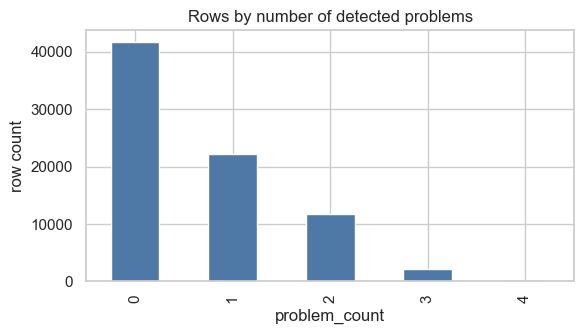

In [69]:
ax = problem_count_table['rows'].plot.bar(figsize=(6, 3.5), color='#4e79a7')
ax.set_title('Rows by number of detected problems')
ax.set_xlabel('problem_count')
ax.set_ylabel('row count')
plt.tight_layout()


In [68]:
flag_columns = [col for col in df_tagged.columns if col.startswith("flag_")]
df_tagged[flag_columns].corr()

,flag_0_days,flag_ratio_problem,flag_zero_opportunity_amount,flag_outlier_opportunity_amount,flag_outlier_total_days,flag_totally_repeated_row,flag_partially_repeated_row,flag_only_identified,flag_weirdness_over_75th_pct
flag_0_days,1.0000,0.6473,0.0642,-0.0194,-0.0653,0.0225,-0.0035,-0.1114,-0.0298
flag_ratio_problem,0.6473,1.0000,0.0438,-0.0063,-0.0362,0.0222,0.0104,-0.1775,-0.0679
flag_zero_opportunity_amount,0.0642,0.0438,1.0000,-0.0526,0.0026,0.0137,0.0354,0.0297,-0.0587
flag_outlier_opportunity_amount,-0.0194,-0.0063,-0.0526,1.0000,0.0301,-0.0021,0.0063,0.0102,0.2747
flag_outlier_total_days,-0.0653,-0.0362,0.0026,0.0301,1.0000,0.0026,0.0025,-0.0105,0.0307
flag_totally_repeated_row,0.0225,0.0222,0.0137,-0.0021,0.0026,1.0000,0.0501,-0.0065,-0.0043
flag_partially_repeated_row,-0.0035,0.0104,0.0354,0.0063,0.0025,0.0501,1.0000,-0.0178,-0.0088
flag_only_identified,-0.1114,-0.1775,0.0297,0.0102,-0.0105,-0.0065,-0.0178,1.0000,0.0707
flag_weirdness_over_75th_pct,-0.0298,-0.0679,-0.0587,0.2747,0.0307,-0.0043,-0.0088,0.0707,1.0000


### Final export configuration
Uncomment any problem labels to remove those rows from the export.
Deduplication by ID (keep latest appearance) is always applied before writing output.


In [70]:
from pathlib import Path

# Select which problems to remove (leave commented to keep all for now)
problems_to_remove = [
    '0_days',
    'ratio_problem',
    'zero_opportunity_amount',
    'outlier_opportunity_amount',
    'outlier_total_days',
    #'totally_repeated_row',
    #'partially_repeated_row',
]

working = df_tagged.copy()

working.to_parquet(Path('../../data/intermediate/df_tagged_full.parquet'), index=False)

if problems_to_remove:
    selected = set(problems_to_remove)
    working = working[~working['problem_tags'].apply(lambda tags: any(t in selected for t in tags))].copy()

# Always deduplicate by ID, keeping the most recent appearance in dataset order
working = (
    working
    .sort_values('Total Days Identified Through Closing', ascending=False)  # Assuming later stages have more days, adjust if needed
    .drop_duplicates(subset=[id_col], keep='last')
)

# Export only original columns to preserve source schema
export_df = working[df.columns.tolist()].copy()

output_path = Path('../../data/intermediate/cleaned_data.parquet')
output_path.parent.mkdir(parents=True, exist_ok=True)
export_df.to_parquet(output_path, index=False)

print(f'Rows before filtering: {len(df_tagged):,}')
print(f'Rows after problem filtering: {len(working):,}')
print(f'Rows exported after latest-per-ID dedup: {len(export_df):,}')
print(f'File written to: {output_path}')



Rows before filtering: 78,025
Rows after problem filtering: 56,376
Rows exported after latest-per-ID dedup: 56,376
File written to: ../../data/intermediate/cleaned_data.parquet


## 6) Quick conclusions

- Dataset loaded as expected: **78,025 rows × 19 columns** (schema stable before checks).
- Target profile shows clear class imbalance: **Loss 77.41% (60,398)** vs **Won 22.59% (17,627)**; `Opportunity Amount USD` is right-skewed (**median 49,000**, **95th pct 350,000**, **99th pct 700,000**).
- IQR outlier concentration is strongest in ratio/day behavior: `Ratio Days Identified` (**14,983 rows**) and `Ratio Days Qualified` (**14,948 rows**), then `Sales Stage Change Count` (**9,340**) and `Opportunity Amount USD` (**7,273**).
- Process consistency is mixed: no negative day values, no `Total Siebel > Total Days`, and no ratios outside \[0,1\]; however **12,921 rows (16.56%)** have ratio sums not close to 1 (tol=0.01, i.e. probably not due to floating point inconsistencies), and **4,127 rows (5.29%)** show >1 day mismatch between implied and recorded total days.
- Early-day segment behaves differently: win probability is **0.4194** for `0-1` days and drops to **0.0712** for `31-60` days, indicating strong duration-related separation in outcomes.
- Dataset is mostly single-slice per `Opportunity Number`, but some duplicates exist, posing potential data leakage risks if not handled properly.
- When measuring the "weirdness/randomness" of `Opportunity Amount USD` based on its digits, we find that it is not purely noise and shows some correlation with other variables, suggesting it captures systematic patterns in the data entry or business process (i.e. maybe salespeople enter more precise amounts for deals they expect to win, or they insert dummy values at the start and update them as the opportunity progresses).
- Final tagging marks **25,787 rows** with ≥1 issue (`problem_count > 0`), while **41,638 rows (56.36%)** have zero flags. Not all flags are actually used, so only **21,649 rows** are filtered and the rest **(56,376 rows)** are exported to `../../data/intermediate/cleaned_data.parquet` with all filters enabled.